In [24]:
# 설치 안 되어 있으면 먼저 실행
# !pip install xgboost

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, f1_score, confusion_matrix
from xgboost import XGBClassifier

# 1. 데이터 불러오기
df = pd.read_csv(r"./data/train_features.csv")

# 2. 불필요한 컬럼 제거
drop_cols = [
    "msno",
    "is_churn",
    "last_tx_date",
    "last_expire_date",
    "last_listen_date"
]

X = df.drop(columns=drop_cols)
y = df["is_churn"]

# 3. 문자형 컬럼 더미화
X = pd.get_dummies(X, drop_first=False)

# 4. 결측치 처리
X = X.fillna(0)

# 5. train / validation 분리
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 6. XGBoost 모델 생성
xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

# 7. 학습
xgb_model.fit(X_train, y_train)

# 8. 예측
pred = xgb_model.predict(X_val)
pred_proba = xgb_model.predict_proba(X_val)[:, 1]

# 9. 평가
print("Confusion Matrix")
print(confusion_matrix(y_val, pred))

print("\nClassification Report")
print(classification_report(y_val, pred))

print("ROC-AUC:", roc_auc_score(y_val, pred_proba))
print("F1-score:", f1_score(y_val, pred))

Confusion Matrix
[[185529    364]
 [  2463  10231]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    185893
           1       0.97      0.81      0.88     12694

    accuracy                           0.99    198587
   macro avg       0.98      0.90      0.94    198587
weighted avg       0.99      0.99      0.99    198587

ROC-AUC: 0.9922164403798754
F1-score: 0.8786122203615441


In [4]:
import sklearn
print(sklearn.__version__)

1.8.0


In [7]:
import os

print(os.getcwd())

c:\documents\SKN31-2nd-4Team


In [10]:
import os

print(os.getcwd())
print(os.listdir())

c:\documents\SKN31-2nd-4Team
['.git', '.gitignore', '.venv', 'data', 'documents.lnk', 'eda.ipynb', 'feature_engineering.py', 'main.py', 'members_v3.csv', 'members_v3_preprocessed.csv', 'models', 'models_train', 'pages', 'README.md', 'requirements.txt', 'results', 'user_log_preprocess.py', 'utils', 'xgboost.ipynb', '실행순서.txt']


In [12]:
df = pd.read_csv("data/train_features.csv")

In [15]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

result_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Score": [
        accuracy_score(y_val, pred),
        precision_score(y_val, pred),
        recall_score(y_val, pred),
        f1_score(y_val, pred),
        roc_auc_score(y_val, pred_proba)
    ]
})

result_df

,Metric,Score
0,Accuracy,0.985764
1,Precision,0.965644
2,Recall,0.805971
3,F1-Score,0.878612
4,ROC-AUC,0.992216


In [16]:
result = pd.DataFrame({
    "Actual": y_val,
    "Predicted": pred,
    "Probability": pred_proba
})

result.head(20)

,Actual,Predicted,Probability
924393,0,0,0.062916
652521,0,0,0.000301
950495,0,0,0.000130
330087,0,0,0.000153
329247,0,0,0.000916
385904,0,0,0.000147
308951,0,0,0.000178
944790,0,0,0.000147
544017,0,0,0.077310
480741,0,0,0.105381


In [17]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(20)

,Feature,Importance
14,days_since_last_tx,0.369471
9,auto_renew_ratio,0.201919
10,cancel_ratio,0.174784
15,days_until_expire,0.065729
19,log_count,0.042331
6,avg_paid,0.019620
3,city,0.019011
7,avg_discount_rate,0.013227
34,age_bucket_~18,0.008672
8,discount_ratio,0.007876


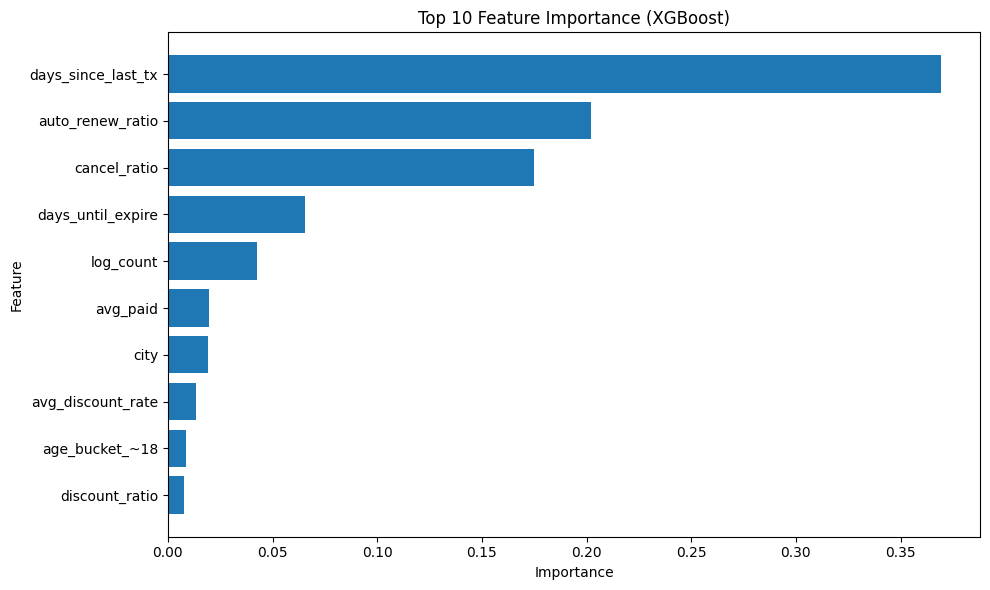

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# 중요도 추출
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

# 중요도 순 정렬 후 상위 10개 선택
top10 = (
    importance_df
    .sort_values("Importance", ascending=False)
    .head(10)
)

# 그래프
plt.figure(figsize=(10, 6))
plt.barh(top10["Feature"], top10["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance (XGBoost)")
plt.gca().invert_yaxis()  # 가장 중요한 변수가 위로 오게
plt.tight_layout()
plt.show()

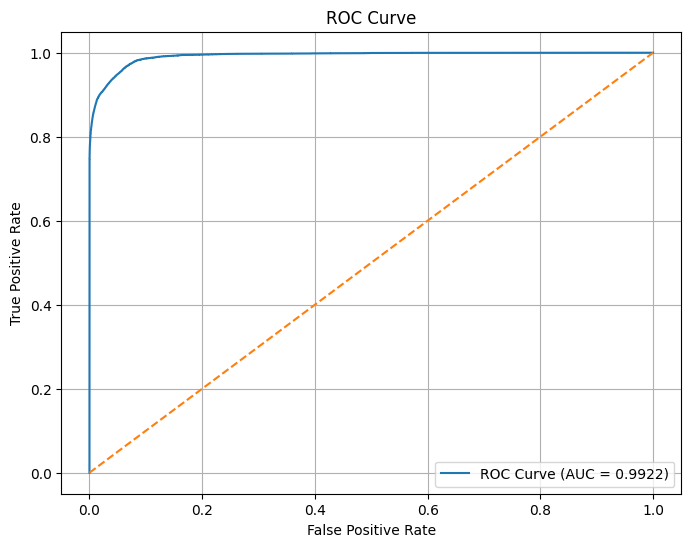

In [20]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# ROC Curve 계산
fpr, tpr, thresholds = roc_curve(y_val, pred_proba)

# AUC 계산
auc_score = roc_auc_score(y_val, pred_proba)

# 그래프
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC Curve (AUC = {auc_score:.4f})"
)

# 랜덤 모델 기준선
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.grid(True)
plt.show()

In [21]:
print("ROC-AUC:", roc_auc_score(y_val, pred_proba))

ROC-AUC: 0.9922164403798754


In [22]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    y_val,
    pred,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df.to_csv(
    "xgboost_classification_report.csv",
    encoding="utf-8-sig"
)

report_df

,precision,recall,f1-score,support
0,0.986898,0.998042,0.992439,185893.000000
1,0.965644,0.805971,0.878612,12694.000000
accuracy,0.985764,0.985764,0.985764,0.985764
macro avg,0.976271,0.902007,0.935526,198587.000000
weighted avg,0.985540,0.985764,0.985163,198587.000000


In [ ]:
# 고객 유지 = 1
# 고객 이탈 = 0
# support= 실제 데이터 개수

In [23]:
import pandas as pd
from sklearn.metrics import log_loss, roc_auc_score, f1_score

# 성능 계산
logloss = log_loss(y_val, pred_proba)
auc = roc_auc_score(y_val, pred_proba)
f1 = f1_score(y_val, pred)

# 한 줄 생성
result = pd.DataFrame({
    "Model": ["XGBoost"],
    "Log Loss": [logloss],
    "AUC": [auc],
    "F1": [f1]
})

# 저장
result.to_csv(
    "results/model_performance.csv",
    index=False,
    encoding="utf-8-sig"
)

In [27]:
import pandas as pd
import os
from sklearn.metrics import log_loss, roc_auc_score, f1_score

# 성능 계산
logloss = log_loss(y_val, pred_proba)
auc = roc_auc_score(y_val, pred_proba)
f1 = f1_score(y_val, pred)

# 한 줄 생성
result = pd.DataFrame({
    "Model":    ["XGBoost"],
    "Log Loss": [logloss],
    "AUC":      [auc],
    "F1":       [f1],
})

# 저장
save_path = "results/model_performance.csv"

if os.path.exists(save_path):
    result.to_csv(save_path, mode='a', header=False, index=False, encoding="utf-8-sig")
else:
    result.to_csv(save_path, mode='w', header=True, index=False, encoding="utf-8-sig")

result

,Model,Log Loss,AUC,F1
0,XGBoost,0.041644,0.992216,0.878612
